In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sns.set_theme(style="darkgrid", palette="colorblind", font_scale=1.1)


# MNIST Benchmark: Standard vs Discrete TM

In [ ]:
api = wandb.Api()

PROJECT = "mayur1009/ytm-benchmark"
runs = api.runs(PROJECT)

frames = []
for run in runs:
    full_run = api.run(f"{PROJECT}/{run.id}")
    config = dict(full_run.config)
    hist = full_run.history()
    hist["approach"] = config.get("approach")
    hist["seed"] = config.get("seed")
    hist["device"] = config.get("device")
    hist["run_id"] = run.id
    frames.append(hist)

df = pd.concat(frames, ignore_index=True)
df = df[df["approach"].notna()]
df["fit/ram_peak_mb"] = df["fit/ram_peak"] / 1024**2
if "fit/vram_peak" in df.columns:
    df["fit/vram_peak_mb"] = df["fit/vram_peak"] / 1024**2

print(f"{len(df)} rows, {df['run_id'].nunique()} runs")
print(f"\nRuns per (approach, device):")
print(df.groupby(["approach", "device"])["run_id"].nunique())

In [ ]:
def plot_comparison(df, metric, ylabel, title, build_df_fn=None):
    """Plot CPU and CUDA side by side with shared y-axis."""
    legend_kw = dict(bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0)
    fig, (ax_cpu, ax_cuda) = plt.subplots(1, 2, figsize=(14, 5), sharey=True, layout="compressed")

    for ax, device in [(ax_cpu, "cpu"), (ax_cuda, "cuda")]:
        df_dev = df[df["device"] == device]
        if df_dev.empty:
            ax.set_title(f"{device.upper()} (no data)")
            continue
        plot_df = build_df_fn(df_dev) if build_df_fn else df_dev
        hue_col = "variant" if "variant" in plot_df.columns else "approach"
        sns.lineplot(data=plot_df, x="epoch", y=metric, hue=hue_col, style=hue_col, markers=True, ax=ax)
        ax.set_xlabel("Epoch")
        ax.set_title(f"{device.upper()}")
        if ax == ax_cuda:
            ax.legend(**legend_kw)
        else:
            ax.legend().remove()

    ax_cpu.set_ylabel(ylabel)
    ax_cuda.set_ylabel("")
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.show()


def plot_memory(df, metric, ylabel, title):
    """Plot CPU and CUDA side by side WITHOUT shared y-axis."""
    legend_kw = dict(bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0)
    fig, (ax_cpu, ax_cuda) = plt.subplots(1, 2, figsize=(14, 5), layout="compressed")

    for ax, device in [(ax_cpu, "cpu"), (ax_cuda, "cuda")]:
        df_dev = df[df["device"] == device]
        if df_dev.empty:
            #ax.set_title(f"{device.upper()} (no data)")
            continue
        plot_df = df_dev.dropna(subset=[metric])
        if plot_df.empty:
            #ax.set_title(f"{device.upper()} (no data)")
            continue
        sns.lineplot(data=plot_df, x="epoch", y=metric, hue="approach", style="approach", markers=True, ax=ax)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{device.upper()}")
        if ax == ax_cuda:
            ax.legend(**legend_kw)
        else:
            ax.legend().remove()

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.show()


def build_fit_time_df(df_dev):
    fit_rows = []
    for _, row in df_dev.iterrows():
        fit_rows.append({"epoch": row["epoch"], "time": row["fit/time"], "variant": row["approach"]})
        if row["approach"] == "standard" and pd.notna(row.get("fit/time_with_encode")):
            fit_rows.append({"epoch": row["epoch"], "time": row["fit/time_with_encode"], "variant": "standard + encode"})
    return pd.DataFrame(fit_rows)

## Comparison Plots

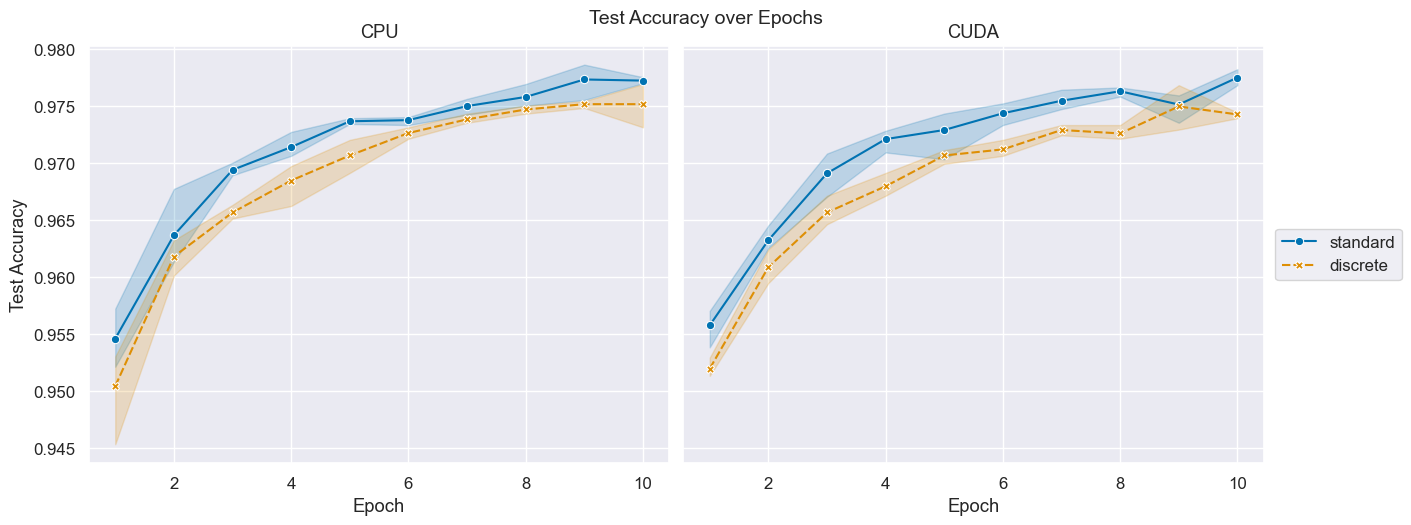

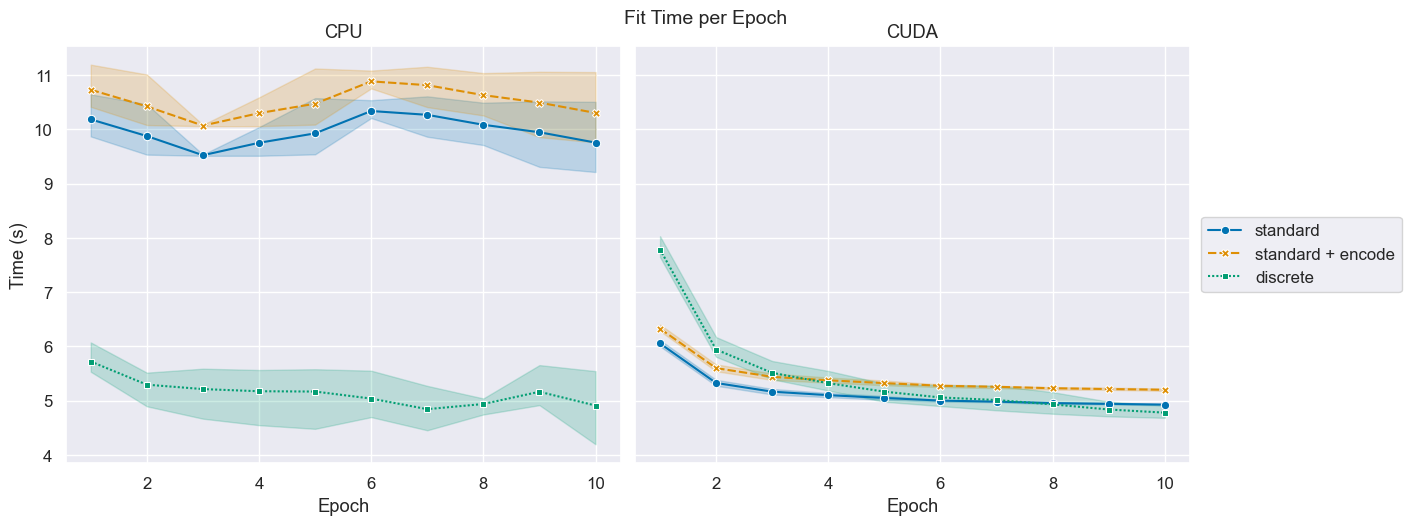

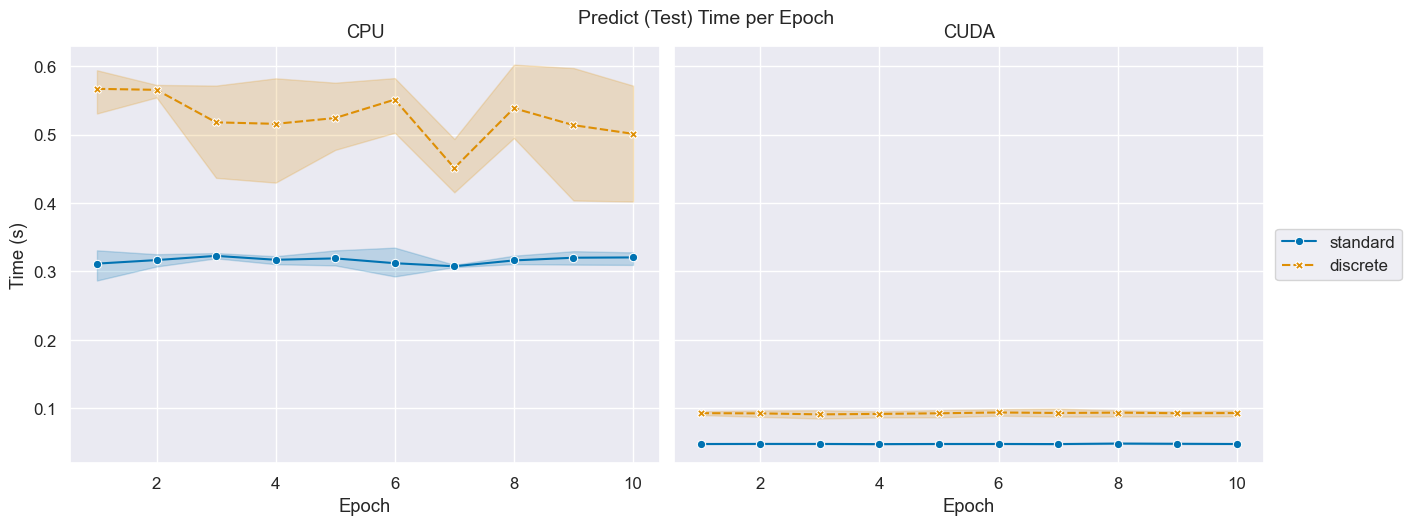

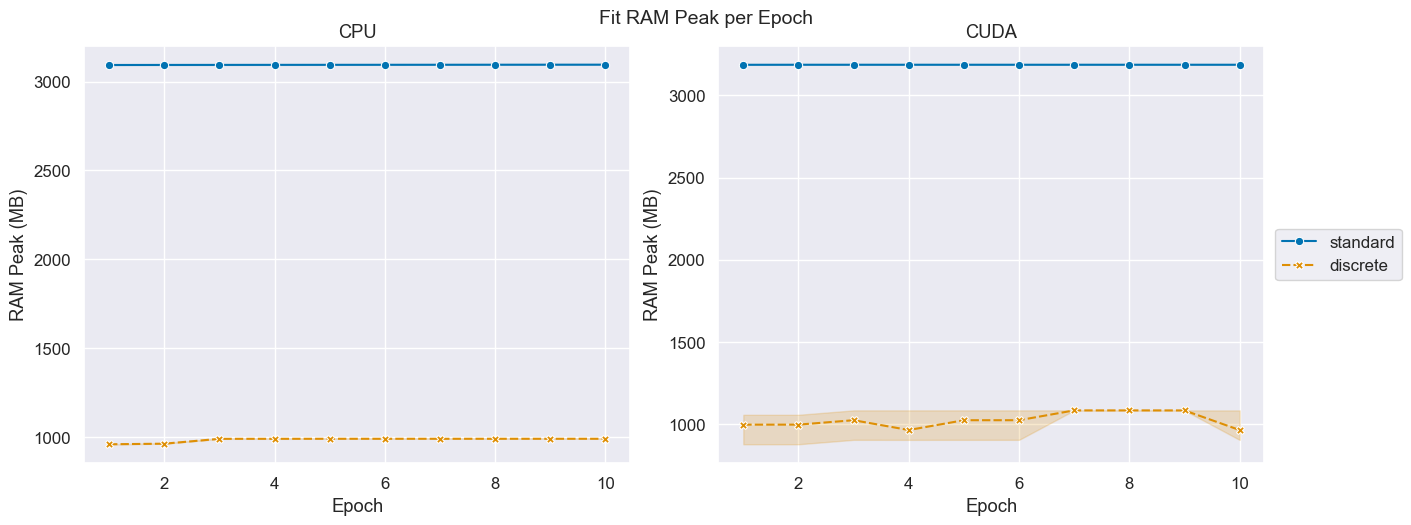

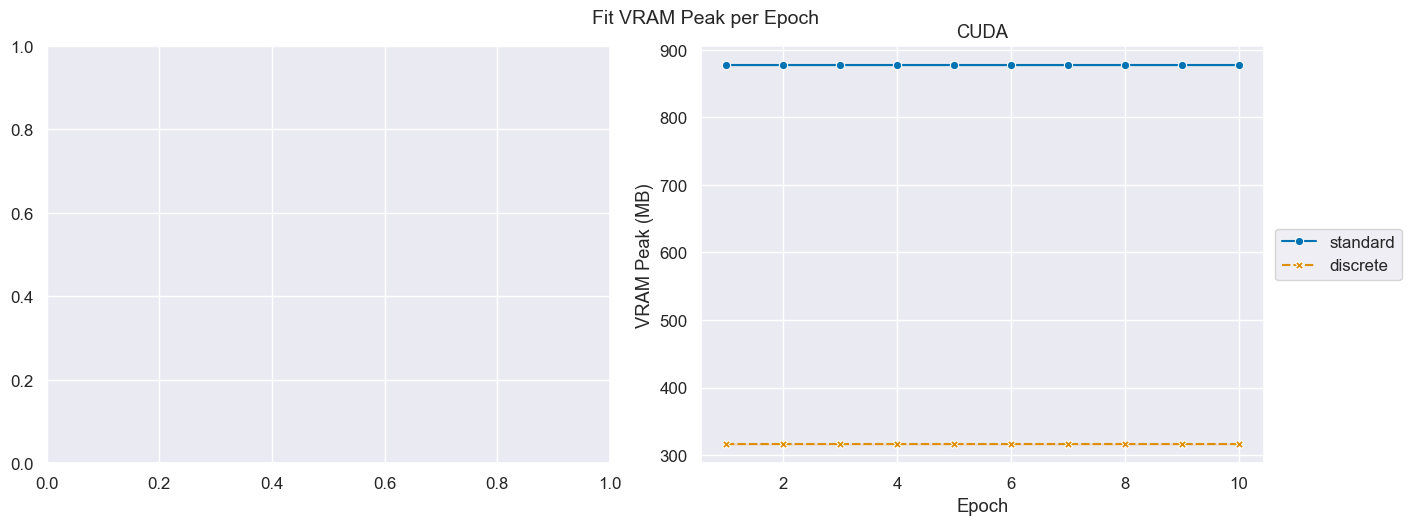

In [ ]:
plot_comparison(df, "test_acc", "Test Accuracy", "Test Accuracy over Epochs")
plot_comparison(df, "time", "Time (s)", "Fit Time per Epoch", build_df_fn=build_fit_time_df)
plot_comparison(df, "predict_test/time", "Time (s)", "Predict (Test) Time per Epoch")
plot_memory(df, "fit/ram_peak_mb", "RAM Peak (MB)", "Fit RAM Peak per Epoch")
plot_memory(df, "fit/vram_peak_mb", "VRAM Peak (MB)", "Fit VRAM Peak per Epoch")

## Summary Tables (last epoch, mean across seeds)

In [ ]:
summary_cols = ["test_acc", "fit/time", "fit/time_with_encode", "predict_test/time", "fit/ram_peak_mb"]

for device in ["cuda", "cpu"]:
    df_dev = df[df["device"] == device]
    if df_dev.empty:
        continue
    last_epoch = df_dev["epoch"].max()
    last = df_dev[df_dev["epoch"] == last_epoch]
    summary = last.groupby("approach")[summary_cols].agg(["mean", "std"])
    summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]
    print(f"\n{'=' * 40}")
    print(f"  {device.upper()} Summary (epoch {int(last_epoch)})")
    print(f"{'=' * 40}")
    display(summary)


  CUDA Summary (epoch 10)


,test_acc_mean,test_acc_std,fit/time_mean,fit/time_std,fit/time_with_encode_mean,fit/time_with_encode_std,predict_test/time_mean,predict_test/time_std,fit/ram_peak_mb_mean,fit/ram_peak_mb_std
approach,,,,,,,,,,
discrete,0.974233,0.000289,4.777320,0.117633,4.777320,0.117633,0.093110,0.004303,961.901042,103.653577
standard,0.977467,0.000702,4.926048,0.013007,5.199702,0.021464,0.047864,0.000281,3187.179688,0.490992



  CPU Summary (epoch 10)


,test_acc_mean,test_acc_std,fit/time_mean,fit/time_std,fit/time_with_encode_mean,fit/time_with_encode_std,predict_test/time_mean,predict_test/time_std,fit/ram_peak_mb_mean,fit/ram_peak_mb_std
approach,,,,,,,,,,
discrete,0.975133,0.001914,4.907987,0.677557,4.907987,0.677557,0.501008,0.088191,989.798177,0.162301
standard,0.977200,0.000361,9.757325,0.671932,10.304072,0.673204,0.320445,0.009668,3095.591146,0.181097
